# Do LLMs Play Nash? Strategic Behavior of Language Models
**CSCE 631 â€” Summer I 2026 | Texas A&M University**

Pipeline:
1. Build the 12-game suite with known Nash equilibria
2. Query the TAMU LLM API â€” GPT models at T=0/0.5/1.0; Claude Sonnet at T=1
3. Compute exploitability of LLM strategies relative to Nash
4. Visualize systematic biases

**Note on temperature:** Claude Sonnet/Opus require `temperature=1` (thinking mode).  
Temperature sweep (T=0, 0.5, 1.0) is done with `protected.gpt-5-mini` to avoid this constraint.  
Claude Sonnet 4.5 is queried separately at T=1 for model comparison.


## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path

from src.games import build_game_suite
from src.solvers import compute_nash_equilibria, compute_exploitability
from src.llm import TAMUClient
from src.llm.response_parser import parse_action_distribution, build_game_prompt
from src.analysis import plot_exploitability_heatmap, plot_strategy_comparison, plot_bias_summary

RESPONSES_DIR = Path('../data/responses')
RESPONSES_DIR.mkdir(parents=True, exist_ok=True)

# Temperature sweep model: GPT (no thinking-mode constraint)
SWEEP_MODEL = 'gpt-mini'          # protected.gpt-5-mini
TEMPERATURES = [0.0, 0.5, 1.0]

# Model comparison at T=1
COMPARE_MODELS = {
    'gpt-mini': 'protected.gpt-5-mini',
    'haiku':    'protected.Claude-Haiku-4.5',
    'sonnet':   'protected.Claude Sonnet 4.5',
}

N_QUERIES = 5   # queries per (game, temperature/model) cell

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Build Game Suite

In [2]:
games = build_game_suite()
print(f'Loaded {len(games)} games:')
for g in games:
    print(f'  [{g.game_type:20s}] {g.name}')

Loaded 12 games:
  [social-dilemma      ] Prisoner's Dilemma (Classic)
  [social-dilemma      ] Prisoner's Dilemma (High Stakes)
  [social-dilemma      ] Prisoner's Dilemma (Low Stakes)
  [coordination        ] Coordination Game
  [coordination        ] Battle of the Sexes
  [coordination        ] Stag Hunt
  [zero-sum            ] Matching Pennies
  [zero-sum            ] Rock-Paper-Scissors
  [bargaining          ] Nash Bargaining (Symmetric Split-100)
  [bargaining          ] Nash Bargaining (Asymmetric)
  [anti-coordination   ] Chicken (Hawk-Dove)
  [general-sum         ] 3x3 General-Sum Game


## 2. Verify Nash Equilibria (no API needed)

In [3]:
game_ne = {}  # game_name -> list of (row_ne, col_ne)

for g in games:
    if g.known_ne:
        ne_list = g.known_ne
    else:
        ne_list = compute_nash_equilibria(g)
    game_ne[g.name] = ne_list

    for (r, c) in ne_list[:1]:  # check first NE only
        eps = compute_exploitability(g, r, c)
        status = 'OK' if eps < 1e-3 else f'WARN eps={eps:.4f}'
        print(f'{g.name:50s} eps={eps:.2e}  [{status}]')

Prisoner's Dilemma (Classic)                       eps=0.00e+00  [OK]
Prisoner's Dilemma (High Stakes)                   eps=0.00e+00  [OK]
Prisoner's Dilemma (Low Stakes)                    eps=0.00e+00  [OK]
Coordination Game                                  eps=0.00e+00  [OK]
Battle of the Sexes                                eps=0.00e+00  [OK]
Stag Hunt                                          eps=0.00e+00  [OK]
Matching Pennies                                   eps=0.00e+00  [OK]
Rock-Paper-Scissors                                eps=0.00e+00  [OK]
Nash Bargaining (Symmetric Split-100)              eps=0.00e+00  [OK]
Nash Bargaining (Asymmetric)                       eps=0.00e+00  [OK]
Chicken (Hawk-Dove)                                eps=0.00e+00  [OK]
3x3 General-Sum Game                               eps=0.00e+00  [OK]


## 3. Query LLM â€” Temperature Sweep (GPT-mini at T=0, 0.5, 1.0)
Cookie required. Set `TAMU_CF_COOKIE` in `.env` before running this cell.

In [17]:
cache_path = RESPONSES_DIR / 'responses_temp_sweep.json'
if cache_path.exists():
    with open(cache_path) as f:
        temp_cache = json.load(f)
    print(f'Loaded cache: {sum(len(v) for v in temp_cache.values())} game entries')
else:
    temp_cache = {}

client = TAMUClient(model=SWEEP_MODEL, temperature=1.0)

for g in tqdm(games, desc='Games'):
    if g.name not in temp_cache:
        temp_cache[g.name] = {}

    prompt = build_game_prompt(
        g.name, g.row_actions, g.col_actions,
        g.row_payoffs, g.col_payoffs, player=1
    )

    for T in TEMPERATURES:
        key = str(T)
        existing = temp_cache[g.name].get(key, [])
        needed = N_QUERIES - len(existing)
        if needed <= 0:
            continue

        responses = list(existing)
        for _ in range(needed):
            resp = client.query_game(prompt, temperature=T)
            responses.append(resp)
            time.sleep(1)  # respect rate limit

        temp_cache[g.name][key] = responses

with open(cache_path, 'w') as f:
    json.dump(temp_cache, f, indent=2)
print(f'Saved. Total tokens used: {client.total_tokens_used:,}')

Loaded cache: 33 game entries


Games: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 12/12 [00:50<00:00,  4.24s/it]

Saved. Total tokens used: 33,900


## 4. Query LLM â€” Model Comparison (GPT-mini vs Haiku vs Sonnet at T=1)

In [6]:
model_cache_path = RESPONSES_DIR / 'responses_model_compare.json'
if model_cache_path.exists():
    with open(model_cache_path) as f:
        model_cache = json.load(f)
else:
    model_cache = {}

for model_key in COMPARE_MODELS:
    client = TAMUClient(model=model_key, temperature=1.0)
    print(f'\nQuerying {client.model_id}...')

    for g in tqdm(games, desc=model_key, leave=False):
        cache_key = f'{model_key}|{g.name}'
        existing = model_cache.get(cache_key, [])
        needed = N_QUERIES - len(existing)
        if needed <= 0:
            continue

        prompt = build_game_prompt(
            g.name, g.row_actions, g.col_actions,
            g.row_payoffs, g.col_payoffs, player=1
        )
        responses = list(existing)
        for _ in range(needed):
            resp = client.query_game(prompt)
            responses.append(resp)
            time.sleep(1)
        model_cache[cache_key] = responses

    print(f'  Tokens used: {client.total_tokens_used:,}')

with open(model_cache_path, 'w') as f:
    json.dump(model_cache, f, indent=2)
print('Model comparison saved.')


Querying protected.gpt-5-mini...


  Tokens used: 52,025

Querying protected.Claude-Haiku-4.5...


  Tokens used: 23,550

Querying protected.Claude Sonnet 4.5...


  Tokens used: 55,560
Model comparison saved.


## 5. Parse Responses â†’ Strategy Distributions

In [19]:
# Temperature sweep strategies: {game_name: {temperature: np.ndarray}}
llm_by_temp = {}
for g in games:
    llm_by_temp[g.name] = {}
    for T in TEMPERATURES:
        responses = temp_cache.get(g.name, {}).get(str(T), [])
        if not responses:
            llm_by_temp[g.name][T] = np.ones(g.num_row_actions) / g.num_row_actions
        else:
            dists = [parse_action_distribution(r, g.row_actions) for r in responses]
            llm_by_temp[g.name][T] = np.mean(dists, axis=0)

# Model comparison strategies: {model_key: {game_name: np.ndarray}}
llm_by_model = {mk: {} for mk in COMPARE_MODELS}
for mk in COMPARE_MODELS:
    for g in games:
        responses = model_cache.get(f'{mk}|{g.name}', [])
        if not responses:
            llm_by_model[mk][g.name] = np.ones(g.num_row_actions) / g.num_row_actions
        else:
            dists = [parse_action_distribution(r, g.row_actions) for r in responses]
            llm_by_model[mk][g.name] = np.mean(dists, axis=0)

print('Parsed all responses.')

Parsed all responses.


## 6. Compute Exploitability

In [20]:
# Exploitability by temperature (GPT-mini)
exploit_by_temp = {}
for g in games:
    exploit_by_temp[g.name] = {}
    col_ne = game_ne[g.name][0][1] if game_ne[g.name] else np.ones(g.num_col_actions) / g.num_col_actions
    for T in TEMPERATURES:
        row_strat = llm_by_temp[g.name][T]
        exploit_by_temp[g.name][T] = compute_exploitability(g, row_strat, col_ne)

# Exploitability by model (at T=1)
exploit_by_model = {mk: {} for mk in COMPARE_MODELS}
for mk in COMPARE_MODELS:
    for g in games:
        col_ne = game_ne[g.name][0][1] if game_ne[g.name] else np.ones(g.num_col_actions) / g.num_col_actions
        row_strat = llm_by_model[mk][g.name]
        exploit_by_model[mk][g.name] = compute_exploitability(g, row_strat, col_ne)

# Summary table
print(f"{'Game':<45} {'T=0':>7} {'T=0.5':>7} {'T=1.0':>7}")
print('-' * 70)
for g in games:
    row = f'{g.name:<45}'
    for T in TEMPERATURES:
        row += f" {exploit_by_temp[g.name][T]:>7.3f}"
    print(row)

Game                                              T=0   T=0.5   T=1.0
----------------------------------------------------------------------
Prisoner's Dilemma (Classic)                    0.000   0.000   0.000
Prisoner's Dilemma (High Stakes)                0.000   0.000   0.000
Prisoner's Dilemma (Low Stakes)                 0.000   0.000   0.000
Coordination Game                               0.000   0.000   0.500
Battle of the Sexes                             0.000   0.000   0.000
Stag Hunt                                       0.000   4.000   4.000
Matching Pennies                                0.000   0.000   0.000
Rock-Paper-Scissors                             0.000   0.000   0.000
Nash Bargaining (Symmetric Split-100)           0.000   0.000   0.000
Nash Bargaining (Asymmetric)                    0.000   0.000   0.000
Chicken (Hawk-Dove)                             0.000   0.500   0.000
3x3 General-Sum Game                            0.000   2.562   0.000


## 7. Visualizations

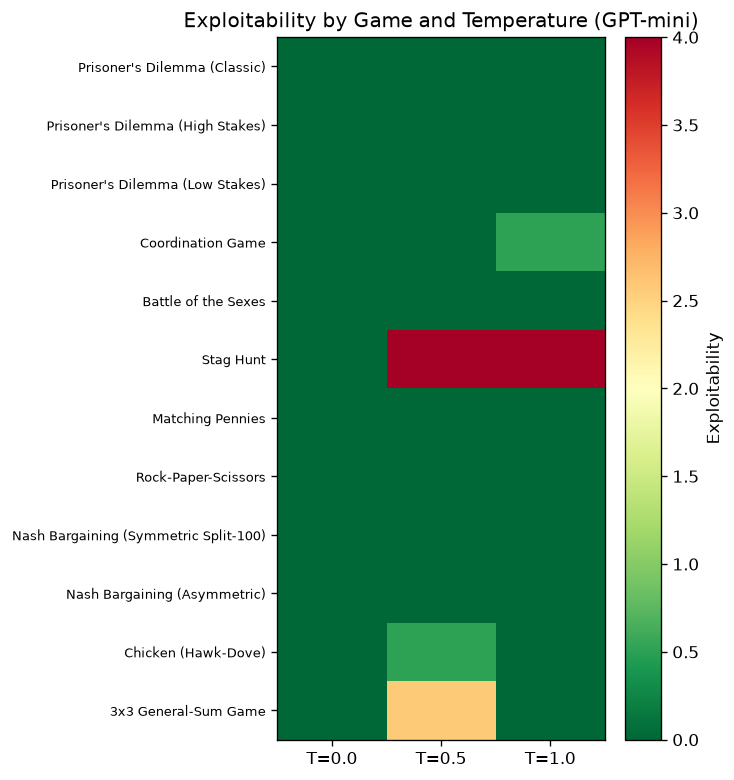

In [21]:
# 7a. Exploitability heatmap â€” temperature sweep
fig, ax = plot_exploitability_heatmap(exploit_by_temp)
ax.set_title('Exploitability by Game and Temperature (GPT-mini)')
plt.savefig('../data/fig_heatmap_temp.png', dpi=150, bbox_inches='tight')
plt.show()

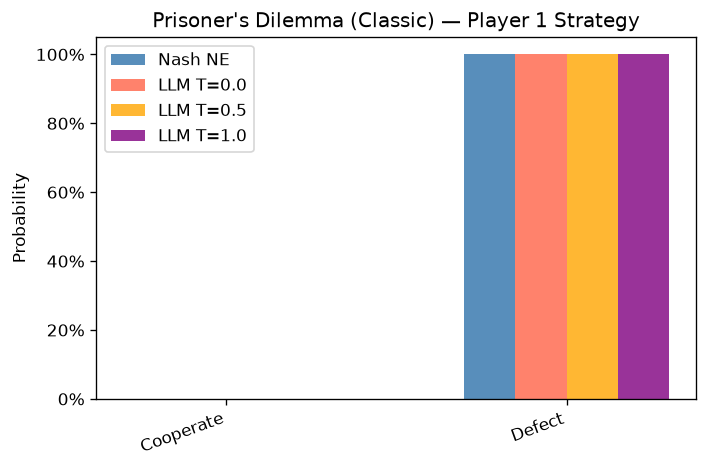

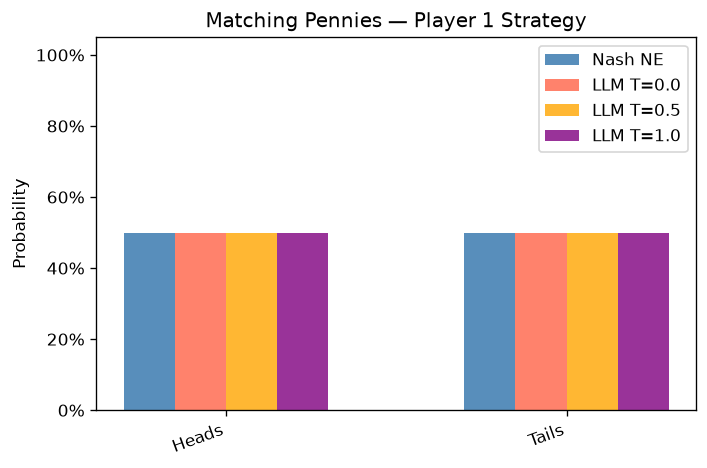

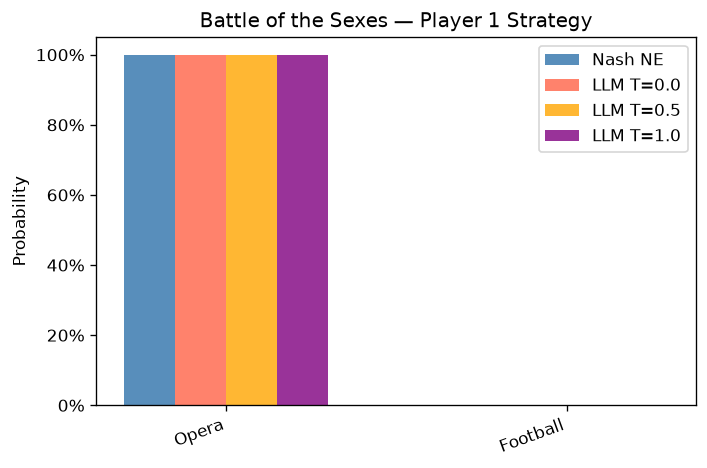

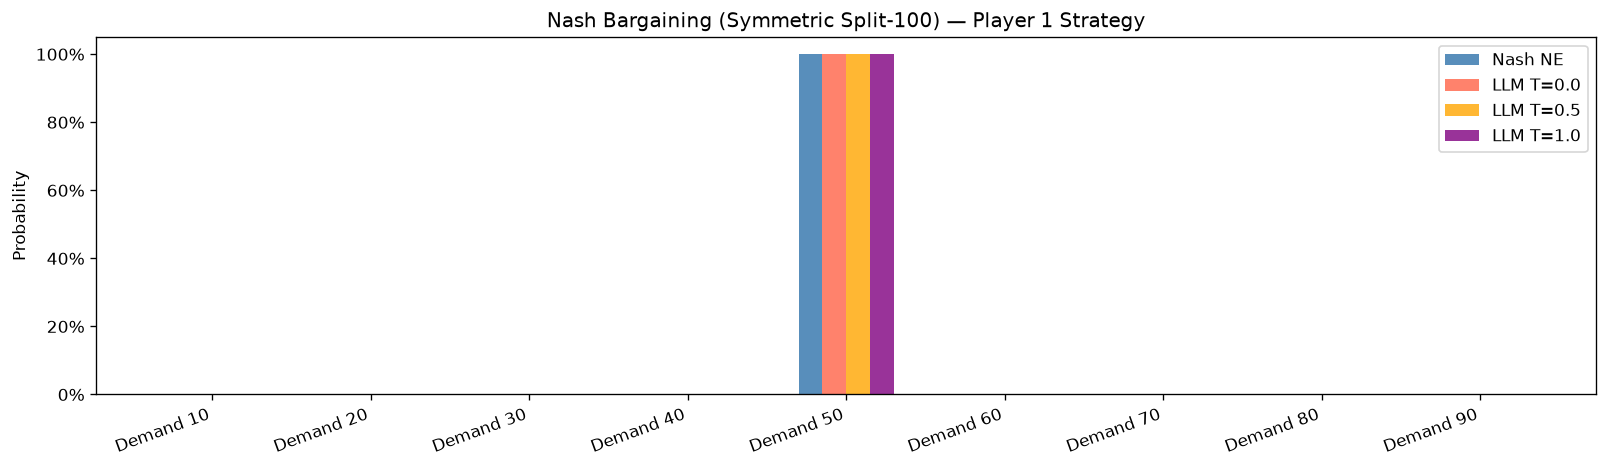

In [26]:
# 7b. Per-game strategy comparison for key games
highlight = [
    "Prisoner's Dilemma (Classic)",
    "Matching Pennies",
    "Battle of the Sexes",
    "Nash Bargaining (Symmetric Split-100)",
]
for gname in highlight:
    g = next(x for x in games if x.name == gname)
    ne_row = game_ne[g.name][0][0] if game_ne[g.name] else np.ones(g.num_row_actions) / g.num_row_actions
    llm_dict = {T: llm_by_temp[g.name][T] for T in TEMPERATURES}
    fig, ax = plot_strategy_comparison(g.name, g.row_actions, ne_row, llm_dict)
    safe_name = gname.replace("'", "").replace("(", "").replace(")", "").replace(" ", "_").replace("-", "_").rstrip("_")[:30]
    plt.savefig(f'../data/fig_strategy_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

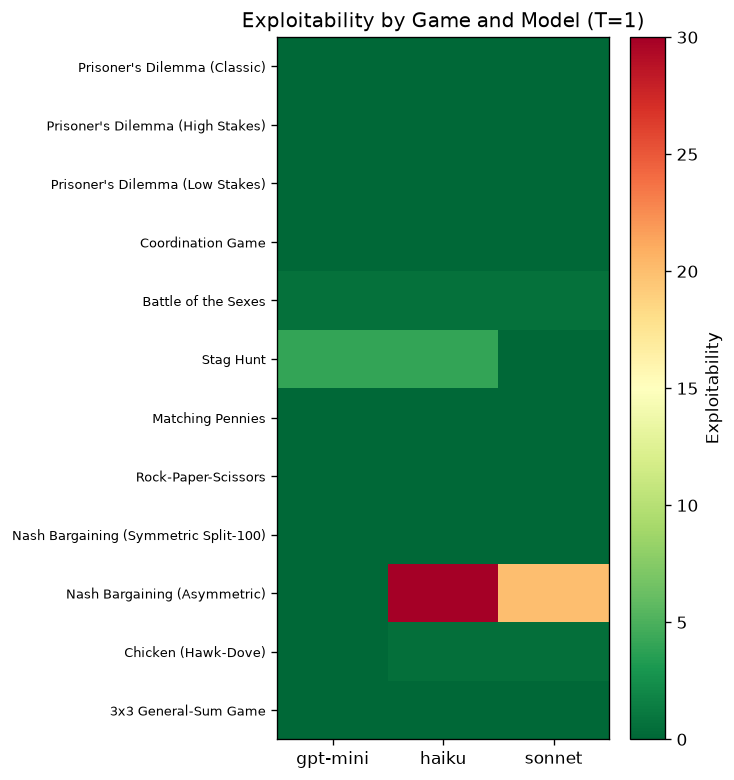

In [24]:
# 7c. Model comparison heatmap at T=1
# Reshape for heatmap: {game_name: {model_label: exploitability}}
model_exploit_reshape = {
    g.name: {mk: exploit_by_model[mk][g.name] for mk in COMPARE_MODELS}
    for g in games
}
fig, ax = plot_exploitability_heatmap(model_exploit_reshape)
ax.set_title('Exploitability by Game and Model (T=1)')
ax.set_xticklabels(list(COMPARE_MODELS.keys()))
plt.savefig('../data/fig_heatmap_models.png', dpi=150, bbox_inches='tight')
plt.show()

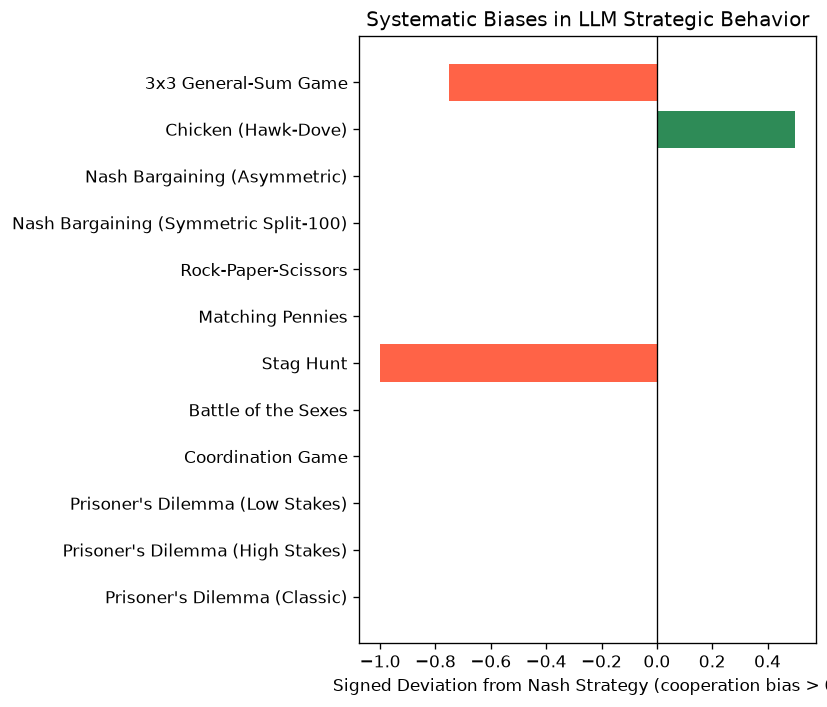

In [25]:
# 7d. Cooperation bias â€” deviation of LLM from NE on first action (T=0.5)
bias_scores = {}
for g in games:
    ne_row = game_ne[g.name][0][0] if game_ne[g.name] else np.ones(g.num_row_actions) / g.num_row_actions
    llm_row = llm_by_temp[g.name][0.5]
    bias_scores[g.name] = float(llm_row[0] - ne_row[0])

fig, ax = plot_bias_summary(bias_scores)
plt.savefig('../data/fig_bias.png', dpi=150, bbox_inches='tight')
plt.show()